In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report


In [58]:
df= pd.read_csv("cleaned_dataset.csv")

In [ ]:

# 2. Select features after hypothesis testing
numerical_features = [
    'Customer_Service_Calls',
    'Cart_Abandonment_Rate',
    'Pages_Per_Session',
    'Session_Duration_Avg',
    'Email_Open_Rate',
    'Mobile_App_Usage',
    'Login_Frequency',
    'Total_Purchases',
    'Days_Since_Last_Purchase'
]

categorical_features = [
    'Signup_Quarter'
]

selected_features = numerical_features + categorical_features

In [60]:
# features seperate 
X= df[selected_features]
y = df['Churned']

In [61]:
# Train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state =42,stratify =y)

In [62]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers= [
        ('num',StandardScaler(),numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        
    ]
)

In [63]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Elbow Method for Finding Best K Value

This section calculates the error rate for different K values and plots the elbow curve.

In [64]:
# Elbow method for selecting best K value

error_rate = []
k_values = range(1, 21)

for k in k_values:
    knn_temp_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', KNeighborsClassifier(n_neighbors=k))
        ]
    )

    knn_temp_pipeline.fit(X_train, Y_train)
    y_pred_k = knn_temp_pipeline.predict(X_test)

    error = 1 - accuracy_score(Y_test, y_pred_k)
    error_rate.append(error)

elbow_df = pd.DataFrame({
    'K_Value': list(k_values),
    'Error_Rate': error_rate
})

elbow_df

,K_Value,Error_Rate
0,1,0.279440
1,2,0.241097
2,3,0.236546
3,4,0.219593
4,5,0.216748
5,6,0.214245
6,7,0.211059
7,8,0.206849
8,9,0.206963
9,10,0.208215


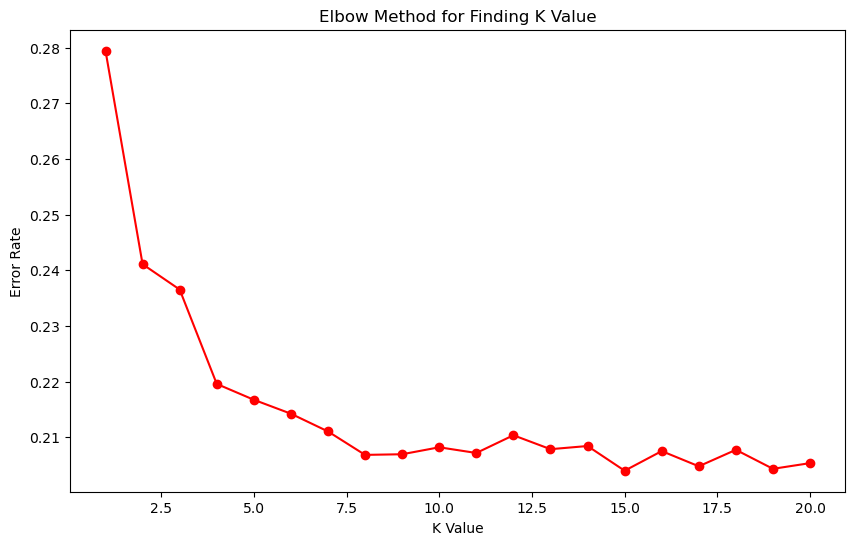

In [65]:
# Plot error rate for different K values
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rate, marker='o',color = 'red')
plt.title('Elbow Method for Finding K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

In [66]:
k =7


In [67]:
# create KNN model pipeline 
knn_pipeline = Pipeline(
    steps =[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ]
)

In [68]:
knn_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
knn_pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
# predict test data
y_pred = knn_pipeline.predict(X_test)

In [71]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(8789,))

In [72]:
# model evaluation 
print("Accuracy: ",accuracy_score(Y_test,y_pred))
print("precision: ",precision_score(Y_test,y_pred))
print("recall: ",recall_score(Y_test,y_pred))
print("F1_score :",f1_score(Y_test,y_pred))

Accuracy:  0.7889407213562407
precision:  0.7204892966360856
recall:  0.45729813664596275
F1_score : 0.559487057706008


In [73]:
print("\nConfusion Matrix:")
cm = confusion_matrix(Y_test, y_pred)
print(confusion_matrix(Y_test, y_pred))


Confusion Matrix:
[[5756  457]
 [1398 1178]]


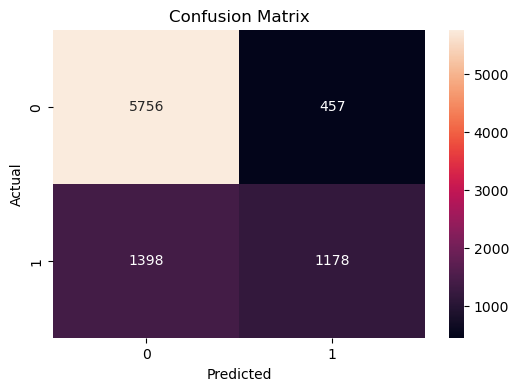

In [74]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      6213
           1       0.72      0.46      0.56      2576

    accuracy                           0.79      8789
   macro avg       0.76      0.69      0.71      8789
weighted avg       0.78      0.79      0.77      8789



In [76]:
# Display final trained KNN pipeline
knn_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### predict in new value 

In [77]:
input_data = {
    'Customer_Service_Calls': [4, 1, 6],
    'Cart_Abandonment_Rate': [0.75, 0.20, 0.90],
    'Pages_Per_Session': [3, 8, 2],
    'Session_Duration_Avg': [5.5, 15.2, 3.1],
    'Email_Open_Rate': [0.20, 0.80, 0.10],
    'Mobile_App_Usage': [1, 5, 0],
    'Login_Frequency': [2, 12, 1],
    'Total_Purchases': [5, 35, 2],
    'Days_Since_Last_Purchase': [60, 7, 120],
    'Signup_Quarter': ['Q2', 'Q1', 'Q4']
}


In [78]:
X_new = pd.DataFrame(input_data)

In [79]:
new_pred = knn_pipeline.predict(X_new)

In [80]:
X_new['Predicted_Churn'] = new_pred

In [81]:
X_new['Prediction_Result'] = X_new['Predicted_Churn'].map({
    0: 'Not Churned',
    1: 'Churned'
})

In [82]:
X_new

,Customer_Service_Calls,Cart_Abandonment_Rate,Pages_Per_Session,Session_Duration_Avg,Email_Open_Rate,Mobile_App_Usage,Login_Frequency,Total_Purchases,Days_Since_Last_Purchase,Signup_Quarter,Predicted_Churn,Prediction_Result
0,4,0.75,3,5.5,0.2,1,2,5,60,Q2,0,Not Churned
1,1,0.20,8,15.2,0.8,5,12,35,7,Q1,0,Not Churned
2,6,0.90,2,3.1,0.1,0,1,2,120,Q4,1,Churned
